## Read the dataset

In [0]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [98]:
from google.colab import drive
drive.mount('/gdrive')

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).


In [0]:
FILEPATH = '/gdrive/My Drive/GreatLearning/NNDL_Proj 1/bank.csv'
bank_df = pd.read_csv(FILEPATH)

In [101]:
bank_df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [102]:
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
RowNumber          10000 non-null int64
CustomerId         10000 non-null int64
Surname            10000 non-null object
CreditScore        10000 non-null int64
Geography          10000 non-null object
Gender             10000 non-null object
Age                10000 non-null int64
Tenure             10000 non-null int64
Balance            10000 non-null float64
NumOfProducts      10000 non-null int64
HasCrCard          10000 non-null int64
IsActiveMember     10000 non-null int64
EstimatedSalary    10000 non-null float64
Exited             10000 non-null int64
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [103]:
# Check if there are any missing values
bank_df.isnull().values.any()

False

## Drop the columns which are unique for all users like IDs (5 points)

In [104]:
# Drop the columns which are not relevant for the model, as they have unique values 
bank_df.drop(['RowNumber', 'CustomerId', 'Surname'], axis = 1, inplace = True) 
bank_df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Distinguish the feature and target set (5 points)

In [0]:
# Exited indicates the churn. It will be the target-set. 
X =  bank_df.drop("Exited", axis=1)
y =  bank_df['Exited']

### Check the distribution of the target-variable

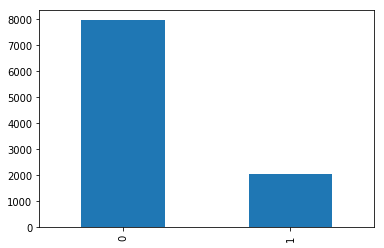

In [106]:
# Displays customer distribution based on churn 
y.value_counts().plot(kind = 'bar')

### PreProcess the X for Categorical Variables 

In [107]:
# Geography is a categorical varibale. Should convert using to_categorical

# First convert the Geography column using LabelEncoder
from sklearn.preprocessing import LabelEncoder
labelencoder_x1 = LabelEncoder()
X.iloc[:, 1] = labelencoder_x1.fit_transform(X.iloc[:, 1])

# Gender is a categorical varibale. Should convert using label-encoder. No need to do one-hot-encoding, as its only binary value
labelencoder_x2 = LabelEncoder()
X.iloc[:, 2] = labelencoder_x2.fit_transform(X.iloc[:, 2])
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,0,42,2,0.00,1,1,1,101348.88
1,608,2,0,41,1,83807.86,1,0,1,112542.58
2,502,0,0,42,8,159660.80,3,1,0,113931.57
3,699,0,0,39,1,0.00,2,0,0,93826.63
4,850,2,0,43,2,125510.82,1,1,1,79084.10


In [108]:
import tensorflow as tf

#Do one-hot-encoding of the Geography Column and add into the dataframe
encoded_df = pd.DataFrame(tf.keras.utils.to_categorical(X.iloc[:, 1]))
X = pd.concat([encoded_df, X], axis = 1)
X.head()

,0,1,2,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,1.0,0.0,0.0,619,0,0,42,2,0.00,1,1,1,101348.88
1,0.0,0.0,1.0,608,2,0,41,1,83807.86,1,0,1,112542.58
2,1.0,0.0,0.0,502,0,0,42,8,159660.80,3,1,0,113931.57
3,1.0,0.0,0.0,699,0,0,39,1,0.00,2,0,0,93826.63
4,0.0,0.0,1.0,850,2,0,43,2,125510.82,1,1,1,79084.10


In [109]:
# Drop the existing Geography Column
X.drop(['Geography'], axis = 1, inplace = True) 
X.head()

,0,1,2,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,1.0,0.0,0.0,619,0,42,2,0.00,1,1,1,101348.88
1,0.0,0.0,1.0,608,0,41,1,83807.86,1,0,1,112542.58
2,1.0,0.0,0.0,502,0,42,8,159660.80,3,1,0,113931.57
3,1.0,0.0,0.0,699,0,39,1,0.00,2,0,0,93826.63
4,0.0,0.0,1.0,850,0,43,2,125510.82,1,1,1,79084.10


## Divide the data set into Train and test sets

In [0]:
# Split the data into Train/Test Sets 

from sklearn.model_selection import train_test_split
rand = 5
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, y, test_size = 0.3, random_state = rand)

## Normalize the train and test data (5 points)

In [0]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
Xtrain = sc.fit_transform(Xtrain)
Xtest = sc.transform(Xtest)

## Initialize & build the model (10 points)

In [112]:
#Initialize Sequential model
model = tf.keras.models.Sequential()

# set the model dense layers 
model.add(tf.keras.layers.Dense(12, input_dim=12, activation='relu'))
model.add(tf.keras.layers.Dense(8, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

# Add sgd optimizer 
sgd = tf.keras.optimizers.SGD(lr=0.00001, decay=1e-6, momentum=0.9)

# Compile model
model.compile(loss='binary_crossentropy', optimizer=sgd, metrics=['accuracy'])

#Fit the model
model.fit(Xtrain, Ytrain, epochs=20, batch_size=10, validation_data=(Xtest,Ytest))

Train on 7000 samples, validate on 3000 samples
Epoch 1/20
7000/7000 [==============================] - 1s 191us/sample - loss: 0.8672 - acc: 0.3329 - val_loss: 0.8408 - val_acc: 0.3447
Epoch 2/20
7000/7000 [==============================] - 1s 161us/sample - loss: 0.8119 - acc: 0.3840 - val_loss: 0.7905 - val_acc: 0.4063
Epoch 3/20
7000/7000 [==============================] - 1s 161us/sample - loss: 0.7671 - acc: 0.4343 - val_loss: 0.7494 - val_acc: 0.4613
Epoch 4/20
7000/7000 [==============================] - 1s 180us/sample - loss: 0.7306 - acc: 0.4920 - val_loss: 0.7156 - val_acc: 0.5093
Epoch 5/20
7000/7000 [==============================] - 1s 170us/sample - loss: 0.7005 - acc: 0.5423 - val_loss: 0.6876 - val_acc: 0.5593
Epoch 6/20
7000/7000 [==============================] - 1s 162us/sample - loss: 0.6755 - acc: 0.5899 - val_loss: 0.6643 - val_acc: 0.6120
Epoch 7/20
7000/7000 [==============================] - 1s 164us/sample - loss: 0.6545 - acc: 0.6316 - val_loss: 0.6444 - va

In [113]:
score = model.evaluate(Xtrain, Ytrain, verbose=0)
print ("Accuracy-Score=", score[1])

Accuracy-Score= 0.79157144


## Optimize the model (Optional)

In [114]:
 #Initialize Sequential model
model = tf.keras.models.Sequential()

# set the model dense layers 
model.add(tf.keras.layers.Dense(12, input_dim=12, activation='relu'))
model.add(tf.keras.layers.Dense(8, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
 
# Compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

#Fit the model
model.fit(Xtrain, Ytrain, epochs=20, batch_size=10, validation_data=(Xtest,Ytest))

Train on 7000 samples, validate on 3000 samples
Epoch 1/20
7000/7000 [==============================] - 2s 224us/sample - loss: 0.4919 - acc: 0.7894 - val_loss: 0.4380 - val_acc: 0.8013
Epoch 2/20
7000/7000 [==============================] - 1s 166us/sample - loss: 0.4360 - acc: 0.8020 - val_loss: 0.4225 - val_acc: 0.8113
Epoch 3/20
7000/7000 [==============================] - 1s 164us/sample - loss: 0.4190 - acc: 0.8154 - val_loss: 0.4049 - val_acc: 0.8243
Epoch 4/20
7000/7000 [==============================] - 1s 160us/sample - loss: 0.3990 - acc: 0.8344 - val_loss: 0.3859 - val_acc: 0.8393
Epoch 5/20
7000/7000 [==============================] - 1s 158us/sample - loss: 0.3764 - acc: 0.8441 - val_loss: 0.3679 - val_acc: 0.8463
Epoch 6/20
7000/7000 [==============================] - 1s 158us/sample - loss: 0.3618 - acc: 0.8527 - val_loss: 0.3608 - val_acc: 0.8523
Epoch 7/20
7000/7000 [==============================] - 1s 172us/sample - loss: 0.3538 - acc: 0.8560 - val_loss: 0.3595 - va

In [115]:
score = model.evaluate(Xtrain, Ytrain, verbose=0)
print ("Accuracy-Score=", score[1])

Accuracy-Score= 0.8657143


## Predict the results using 0.5 as a threshold (Optional)

In [116]:
y_pred = model.predict(Xtest)
y_pred = (y_pred > 0.5) #classify based on threshold of 0.5
y_pred

array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]])

## Print the Accuracy score and confusion matrix (5 points)

In [117]:
# confusion matrix 
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Ytest, y_pred)
print (cm)

[[2279  124]
 [ 316  281]]


In [119]:
from sklearn import metrics

#predicting the results
acc_score = metrics.accuracy_score(Ytest,y_pred)
print ("Acccuray-Score =", acc_score)

Acccuray-Score = 0.8533333333333334
